# Protecting Quantum Information: A Hands-On Introduction to Quantum Error Correction with Qiskit

Quantum computers store information in physical systems: superconducting circuits, ions, photons, atoms, spins, and other devices. Physical systems are never perfectly isolated. A qubit can be changed by a stray interaction with its environment, an imperfect gate, a measurement error, or a short loss of coherence.

This notebook introduces the first idea behind quantum error correction (QEC): protect one logical bit of quantum information by spreading it across several physical qubits and decoding the result. We will use a three-qubit repetition code because it is small enough to draw, simulate, and run as a tiny optional IBM hardware experiment.

Our goal is to learn the basic pattern:

1. encode information into more qubits;
2. add a simple noise model;
3. decode measurement results;
4. compare physical and logical error rates.

**What you will run:** an unencoded one-qubit memory experiment and a three-qubit encoded memory experiment, both tested with a bit-flip noise model in Qiskit Aer.


## Prerequisites and dependencies

You should be comfortable with Python functions, simple probability, and the idea that a qubit measured in the computational basis gives either `0` or `1`.

Install the tutorial dependencies with:

```bash
python -m pip install -r requirements-qec-tutorial.txt
```

The simulator part uses `qiskit`, `qiskit-aer`, `numpy`, `matplotlib`, and `pandas`. The optional hardware section uses `qiskit-ibm-runtime`, but it is disabled by default and does not need IBM credentials to run the notebook.


In [2]:
!python -m pip install -r requirements-qec-tutorial.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 15.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 109.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.8/118.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 30.1 MB/s eta 0:00:00
   ━━━━━

In [3]:
from __future__ import annotations

import math
import os
from pathlib import Path
from typing import Mapping, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import qiskit
import qiskit_aer
from qiskit import QuantumCircuit
from qiskit_aer.noise import NoiseModel, pauli_error
from qiskit_aer.primitives import SamplerV2 as AerSampler

SEED = 52
SHOTS = 4_000

cwd = Path.cwd()
REPO_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
ASSET_DIR = REPO_ROOT / "assets" / "images" / "qec-basics"
ASSET_DIR.mkdir(parents=True, exist_ok=True)

print(f"Qiskit version: {qiskit.__version__}")
print(f"Qiskit Aer version: {qiskit_aer.__version__}")
print(f"Figures will be saved in: {ASSET_DIR}")


Qiskit version: 2.4.1
Qiskit Aer version: 0.17.2
Figures will be saved in: /content/assets/images/qec-basics


## 1. Why errors matter

Classical computers already fight errors. A bit stored in memory can flip from `0` to `1`, or a message sent across a network can lose a symbol. Classical error correction handles this by adding extra information. For example, sending `000` instead of one `0` lets a receiver correct one flipped bit by majority vote.

Qubits are more delicate than classical bits. A qubit can have bit-flip errors, phase-flip errors, coherent over-rotations, measurement errors, crosstalk from nearby qubits, and decoherence. Also, an unknown quantum state cannot be copied perfectly. This is the no-cloning theorem, and it means quantum error correction cannot simply make backup copies of an arbitrary qubit.

The QEC idea is different from copying. We encode one **logical qubit** into several **physical qubits**. Then we learn information about the error without directly measuring the protected logical state. In large QEC codes, that error information is called a **syndrome**. In this first notebook, our syndrome will be simple: after measurement, we ask which value appears in the majority.


#2. Physical vs Logical qubits

One of the biggest challenges in quantum computing is that qubits
are extremely fragile.

Heat, noise, imperfect control signals, and interactions with the
environment can easily damage quantum information.

This is why quantum error correction is necessary.


===============================================================
What is a physical qubit?
===============================================================

A physical qubit is the actual real hardware qubit inside the
quantum computer.

Examples include:
- one superconducting circuit,
- one neutral atom,
- one trapped ion,
- or one electron spin.

A physical qubit is the real physical system that stores quantum
information.

However, physical qubits are noisy and unreliable.


===============================================================
What is a logical qubit?
===============================================================

A logical qubit is a protected qubit created using many physical
qubits working together.

The goal is to safely store one piece of quantum information even
if some physical qubits experience errors.

You can think of it like:
- backup copies,
- error checking,
- and automatic repair systems
working together to protect important information.

So:

    physical qubits = real hardware qubits

    logical qubit = protected quantum information built from
                    many physical qubits


===============================================================
How is a logical qubit created?
===============================================================

The quantum information is spread across multiple physical qubits
using a quantum error-correcting code.

One simple example is the three-qubit repetition code.

Instead of storing:

    |0>

in one physical qubit, we encode it as:

    |000>

Similarly:

    |1>

is encoded as:

    |111>

Here:
- 3 physical qubits
represent:
- 1 protected logical qubit.

The logical information is distributed across all the qubits
together.


## 3. What is the three-qubit repetition code?


The three-qubit repetition code is one of the simplest examples
of quantum error correction.

The main idea is very similar to repeating an important message
multiple times so that one mistake can be detected and corrected.

Imagine sending the message:

    "YES"

only once.

If noise changes one letter, the message may become wrong.

Instead, imagine sending:

    "YES YES YES"

Now if one copy gets damaged, the majority vote can still recover
the correct message.

The three-qubit repetition code works similarly.

Instead of storing information in one qubit, we spread the
information across three qubits.

For example:

    |0> becomes |000>

    |1> becomes |111>

If one qubit accidentally flips because of noise:

    |000> -> |001>

the system can still notice that most qubits remain 0.

Using majority voting, the error can be corrected.

This code can correct one bit-flip error.

The repetition code is important because it introduces the central
idea of quantum error correction:

    protect fragile quantum information by spreading it across
    multiple physical qubits.
"""

# ============================================================
# How does the three-qubit repetition code detect an error?
# ============================================================

"""
This is a very important question.

At first, it may seem confusing:

    "How does the system know whether a qubit flipped by mistake
    or whether the information was already correct?"

The key idea is that quantum error correction does NOT directly
look at the original quantum information itself.

Instead, it checks whether the qubits still agree with each other.

Think about a classroom voting example.

Suppose three students are supposed to hold the same answer card:

    YES   YES   YES

If one student accidentally changes their card:

    YES   YES   NO

the teacher notices that one answer does not match the others.

The teacher does not need to know the original message beforehand.

The teacher only checks whether the students still agree.

The three-qubit repetition code works similarly.

For example:

    |0> is encoded as |000>

    |1> is encoded as |111>

Notice something important:

In the correct encoded states:
- all qubits match each other.

Either:
    000

or:
    111

Now imagine one qubit flips because of noise:

    000 -> 001

or:

    111 -> 101

Now one qubit disagrees with the others.

The quantum computer detects this disagreement.

This is done using measurements called syndrome measurements.

The syndrome measurement does NOT directly measure the quantum
information itself.

Instead, it checks relationships between qubits, such as:

    "Do qubit 1 and qubit 2 match?"

    "Do qubit 2 and qubit 3 match?"

This is extremely important.

If we directly measured the quantum state itself, the fragile
quantum information would collapse and be destroyed.

So quantum error correction carefully measures only the error
pattern, not the stored quantum information.

For example:

    000  -> all qubits agree
    111  -> all qubits agree

But:

    001  -> last qubit disagrees
    010  -> middle qubit disagrees
    100  -> first qubit disagrees

From the disagreement pattern, the computer can identify which
qubit most likely flipped.

Then it applies a correction.

This process is called quantum error detection and correction.


## 4. A tiny code: the three-qubit repetition code

The three-qubit bit-flip repetition code stores one logical bit in three physical qubits:

$$
|0_L\rangle = |000\rangle, \qquad |1_L\rangle = |111\rangle.
$$

Here the subscript $L$ means "logical". The three physical qubits are the actual qubits in the circuit. The logical qubit is the encoded information we care about.

If one physical qubit flips, then `000` might become `001`, `010`, or `100`. A majority vote still decodes this as logical `0`. If two or three physical qubits flip, the majority vote gives the wrong logical value.

For independent bit flips with probability $p$ on each physical qubit:

- an unencoded bit fails with probability $p$;
- a three-qubit majority-vote code fails when two or three qubits flip:

$$
P_{\text{fail},3}(p) = 3p^2(1-p) + p^3 = 3p^2 - 2p^3.
$$

This code helps when $p < 1/2$. It also uses more qubits, and a real device would add noise during the extra gates. This toy model is useful because the main idea can be checked exactly.


In [4]:
def repetition_logical_failure_probability(n: int, p: float) -> float:
    """Return the majority-vote failure probability for an odd repetition code."""
    if n % 2 != 1 or n < 1:
        raise ValueError("n must be a positive odd integer")
    if not 0.0 <= p <= 1.0:
        raise ValueError("p must be between 0 and 1")

    first_bad_weight = (n + 1) // 2
    return sum(
        math.comb(n, k) * (p**k) * ((1 - p) ** (n - k))
        for k in range(first_bad_weight, n + 1)
    )

assert repetition_logical_failure_probability(1, 0.23) == 0.23
assert abs(repetition_logical_failure_probability(3, 0.1) - 0.028) < 1e-12
assert repetition_logical_failure_probability(3, 0.1) < 0.1
assert abs(repetition_logical_failure_probability(3, 0.5) - 0.5) < 1e-12


## 5. Build the circuits

The first circuit stores a single physical bit for one memory step. The second circuit stores the same logical value using three physical qubits. The `id` gates mark the memory step. Our noise model will attach bit-flip errors to those `id` gates, so the encoding and measurement are noiseless in the first simulation.


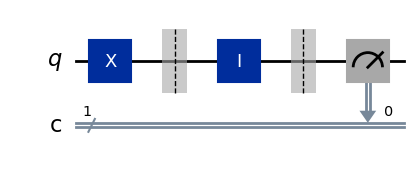

In [5]:
def make_unencoded_memory_circuit(initial_state: int = 0, memory_gates: int = 1) -> QuantumCircuit:
    """Create a one-qubit memory circuit measured in the computational basis."""
    if initial_state not in (0, 1):
        raise ValueError("initial_state must be 0 or 1")
    if memory_gates < 1:
        raise ValueError("memory_gates must be at least 1")

    circuit = QuantumCircuit(1, 1, name=f"unencoded_{initial_state}")
    if initial_state == 1:
        circuit.x(0)
    circuit.barrier()
    for _ in range(memory_gates):
        circuit.id(0)
    circuit.barrier()
    circuit.measure(0, 0)
    return circuit


def make_repetition_memory_circuit(initial_state: int = 0, memory_gates: int = 1) -> QuantumCircuit:
    """Create a three-qubit repetition-code memory circuit."""
    if initial_state not in (0, 1):
        raise ValueError("initial_state must be 0 or 1")
    if memory_gates < 1:
        raise ValueError("memory_gates must be at least 1")

    circuit = QuantumCircuit(3, 3, name=f"repetition3_{initial_state}")
    if initial_state == 1:
        circuit.x(0)

    circuit.cx(0, 1)
    circuit.cx(0, 2)
    circuit.barrier()
    for qubit in range(3):
        for _ in range(memory_gates):
            circuit.id(qubit)
    circuit.barrier()
    circuit.measure([0, 1, 2], [0, 1, 2])
    return circuit


def make_repetition_known_flip_circuit(initial_state: int = 1, flipped_qubit: int = 0) -> QuantumCircuit:
    """Create a repetition-code circuit with one deliberate X before measurement."""
    if flipped_qubit not in (0, 1, 2):
        raise ValueError("flipped_qubit must be 0, 1, or 2")

    circuit = make_repetition_memory_circuit(initial_state=initial_state)
    circuit.name = f"repetition3_known_x_q{flipped_qubit}"
    circuit.data.clear()
    if initial_state == 1:
        circuit.x(0)
    circuit.cx(0, 1)
    circuit.cx(0, 2)
    circuit.barrier()
    circuit.x(flipped_qubit)
    circuit.barrier()
    circuit.measure([0, 1, 2], [0, 1, 2])
    return circuit

unencoded_circuit = make_unencoded_memory_circuit(initial_state=1)
encoded_circuit = make_repetition_memory_circuit(initial_state=1)
known_flip_circuit = make_repetition_known_flip_circuit(initial_state=1, flipped_qubit=0)

assert unencoded_circuit.num_qubits == 1
assert encoded_circuit.num_qubits == 3
assert known_flip_circuit.num_clbits == 3

unencoded_circuit.draw("mpl", idle_wires=True)


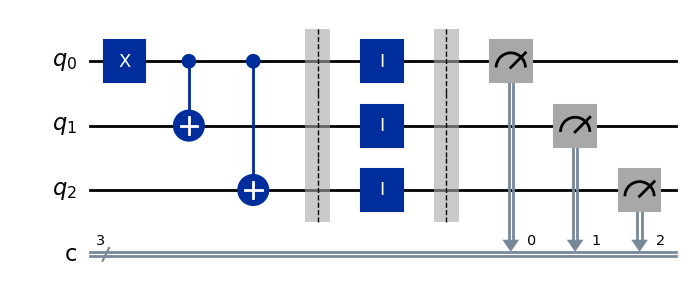

In [6]:
encoded_circuit.draw("mpl", idle_wires=True)


In [7]:
for circuit, filename in [
    (unencoded_circuit, "qec_unencoded_circuit.png"),
    (encoded_circuit, "qec_repetition_circuit.png"),
    (known_flip_circuit, "qec_known_single_flip_circuit.png"),
]:
    figure = circuit.draw("mpl", idle_wires=True, fold=-1)
    figure.savefig(ASSET_DIR / filename, dpi=180, bbox_inches="tight")
    plt.close(figure)

print("Saved circuit diagrams:")
for path in sorted(ASSET_DIR.glob("qec_*circuit.png")):
    print(f"- {path.relative_to(REPO_ROOT)}")


Saved circuit diagrams:
- assets/images/qec-basics/qec_known_single_flip_circuit.png
- assets/images/qec-basics/qec_repetition_circuit.png
- assets/images/qec-basics/qec_unencoded_circuit.png


## 6. Decode measurement results

Qiskit returns counts such as `{'111': 3500, '011': 200, ...}`. For the repetition code, the decoder counts how many `1` values appear in each bitstring. If two or three bits are `1`, it decodes logical `1`; otherwise it decodes logical `0`.

This decoder is intentionally simple. It is a majority-vote decoder, not a full stabilizer decoder.


In [8]:
def decode_majority_vote(bitstring: str) -> int:
    """Decode a measured bitstring by majority vote."""
    cleaned = bitstring.replace(" ", "")
    if not cleaned or any(bit not in "01" for bit in cleaned):
        raise ValueError(f"Invalid bitstring: {bitstring!r}")

    ones = cleaned.count("1")
    zeros = len(cleaned) - ones
    if ones == zeros:
        raise ValueError("Majority vote needs an odd number of bits")
    return int(ones > zeros)


def logical_error_rate(counts: Mapping[str, int], expected_logical_value: int) -> float:
    """Compute the decoded logical error rate from measurement counts."""
    if expected_logical_value not in (0, 1):
        raise ValueError("expected_logical_value must be 0 or 1")
    total = sum(counts.values())
    if total <= 0:
        raise ValueError("counts must contain at least one shot")

    errors = sum(
        count
        for bitstring, count in counts.items()
        if decode_majority_vote(bitstring) != expected_logical_value
    )
    return errors / total

assert decode_majority_vote("0") == 0
assert decode_majority_vote("1") == 1
assert decode_majority_vote("001") == 0
assert decode_majority_vote("101") == 1
assert logical_error_rate({"111": 9, "001": 1}, expected_logical_value=1) == 0.1


## 7. Add a bit-flip noise model

A bit-flip error applies an $X$ gate by accident. The model below adds an $X$ after each `id` gate with probability $p$. This is not a complete hardware noise model. It is a controlled classroom model that lets us test the repetition-code formula.


In [9]:
def make_bitflip_noise_model(p: float) -> NoiseModel:
    """Build an Aer noise model that applies X after each id gate with probability p."""
    if not 0.0 <= p <= 1.0:
        raise ValueError("p must be between 0 and 1")

    error = pauli_error([("X", p), ("I", 1 - p)])
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(error, ["id"])
    return noise_model


def counts_from_sampler_result_item(result_item) -> dict[str, int]:
    """Extract counts from a Qiskit SamplerV2 result item."""
    data = result_item.data
    register_names = list(data.keys())
    if not register_names:
        raise ValueError("Sampler result does not contain classical data")
    bit_array = getattr(data, register_names[0])
    return dict(bit_array.get_counts())


def run_aer_sampler(
    circuits: Sequence[QuantumCircuit],
    p: float,
    shots: int = SHOTS,
    seed: int = SEED,
) -> list[dict[str, int]]:
    """Run circuits with Aer SamplerV2 and the bit-flip noise model."""
    if shots <= 0:
        raise ValueError("shots must be positive")

    sampler = AerSampler(
        default_shots=shots,
        seed=seed,
        options={"backend_options": {"noise_model": make_bitflip_noise_model(p)}},
    )
    result = sampler.run(list(circuits), shots=shots).result()
    return [counts_from_sampler_result_item(item) for item in result]

example_counts = run_aer_sampler(
    [unencoded_circuit, encoded_circuit],
    p=0.12,
    shots=SHOTS,
    seed=SEED,
)

for label, counts in zip(["unencoded", "encoded"], example_counts):
    print(label, counts)
    print("logical error rate:", round(logical_error_rate(counts, expected_logical_value=1), 4))


unencoded {'1': 3539, '0': 461}
logical error rate: 0.1153
encoded {'111': 2697, '101': 362, '011': 388, '110': 389, '010': 50, '001': 50, '100': 59, '000': 5}
logical error rate: 0.041


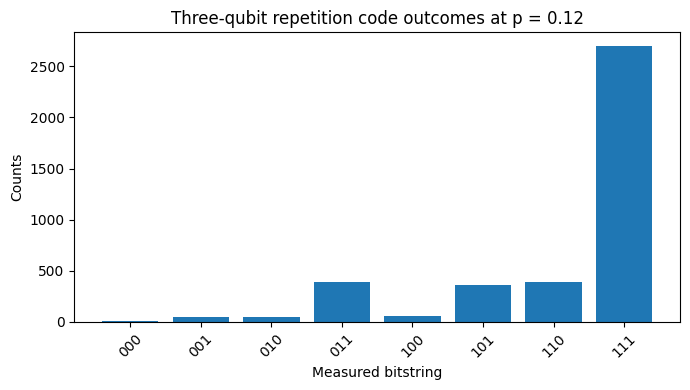

In [10]:
def plot_counts(counts: Mapping[str, int], title: str, filename: str) -> None:
    """Save a count histogram for a small measurement dictionary."""
    labels = sorted(counts)
    values = [counts[label] for label in labels]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(labels, values)
    ax.set_title(title)
    ax.set_xlabel("Measured bitstring")
    ax.set_ylabel("Counts")
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    fig.savefig(ASSET_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

plot_counts(
    example_counts[1],
    "Three-qubit repetition code outcomes at p = 0.12",
    "qec_histogram_p012.png",
)


The encoded histogram has most shots near `111`, plus smaller bars such as `011`, `101`, and `110`, where one physical bit flipped. Majority vote still decodes those one-flip outcomes as logical `1`. Outcomes with two or three flipped bits decode incorrectly.


## 8. Sweep the physical error probability

Now we repeat the experiment for several values of $p$. We compare four quantities:

- simulated unencoded logical error rate;
- simulated three-qubit decoded logical error rate;
- theory for one physical bit, $p$;
- theory for the three-qubit code, $3p^2 - 2p^3$.

Finite-shot sampling means the simulated points will not land exactly on the theory curves.


In [11]:
p_values = np.linspace(0.0, 0.5, 11)
records: list[dict[str, float]] = []

for index, p in enumerate(p_values):
    unencoded_counts, encoded_counts = run_aer_sampler(
        [unencoded_circuit, encoded_circuit],
        p=float(p),
        shots=SHOTS,
        seed=SEED + index,
    )
    records.append(
        {
            "p": float(p),
            "unencoded_sim": logical_error_rate(unencoded_counts, expected_logical_value=1),
            "encoded_sim": logical_error_rate(encoded_counts, expected_logical_value=1),
            "unencoded_theory": float(p),
            "encoded_theory": repetition_logical_failure_probability(3, float(p)),
        }
    )

results = pd.DataFrame.from_records(records)
display(results.round(4))

max_unencoded_gap = float(np.max(np.abs(results["unencoded_sim"] - results["unencoded_theory"])))
max_encoded_gap = float(np.max(np.abs(results["encoded_sim"] - results["encoded_theory"])))
assert max_unencoded_gap < 0.04
assert max_encoded_gap < 0.04


,p,unencoded_sim,encoded_sim,unencoded_theory,encoded_theory
0,0.00,0.0000,0.0000,0.00,0.0000
1,0.05,0.0425,0.0072,0.05,0.0073
2,0.10,0.0965,0.0250,0.10,0.0280
3,0.15,0.1430,0.0590,0.15,0.0608
4,0.20,0.2088,0.1135,0.20,0.1040
5,0.25,0.2547,0.1478,0.25,0.1562
6,0.30,0.3198,0.2115,0.30,0.2160
7,0.35,0.3558,0.2932,0.35,0.2818
8,0.40,0.3952,0.3512,0.40,0.3520
9,0.45,0.4462,0.4200,0.45,0.4253


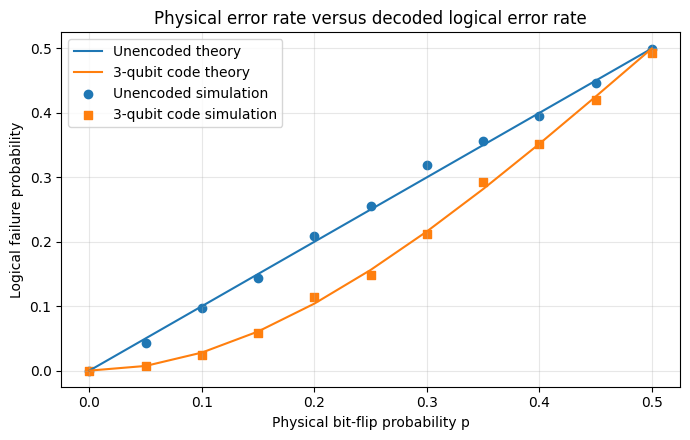

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(results["p"], results["unencoded_theory"], linestyle="-", label="Unencoded theory")
ax.plot(results["p"], results["encoded_theory"], linestyle="-", label="3-qubit code theory")
ax.scatter(results["p"], results["unencoded_sim"], marker="o", label="Unencoded simulation")
ax.scatter(results["p"], results["encoded_sim"], marker="s", label="3-qubit code simulation")
ax.set_xlabel("Physical bit-flip probability p")
ax.set_ylabel("Logical failure probability")
ax.set_title("Physical error rate versus decoded logical error rate")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(ASSET_DIR / "qec_physical_vs_logical.png", dpi=180, bbox_inches="tight")
plt.show()


For small $p$, the encoded curve is below the unencoded curve. This is the core lesson of the repetition code: using three physical qubits can reduce the logical error rate when the physical error rate is low enough. At $p = 0.5$, random guessing wins no advantage, and both curves meet at $0.5$.

The experiment is deliberately idealized. We did not add gate errors to the encoding circuit. On real hardware, the extra gates and measurements also introduce errors.


## 9. Miniature version of a modern QEC benchmark

Modern QEC experiments often ask whether the logical error rate improves when the code distance increases or when repeated syndrome measurements are used. A full state-of-the-art replication needs many qubits, many measurement rounds, calibrated devices, and careful decoding.

We can still reproduce the smallest conceptual version in a classical simulation of repetition codes: compare one physical bit with odd repetition codes of length 3, 5, and 7. This is not a surface-code threshold theorem. It is a threshold-style teaching plot for independent bit flips and majority vote.


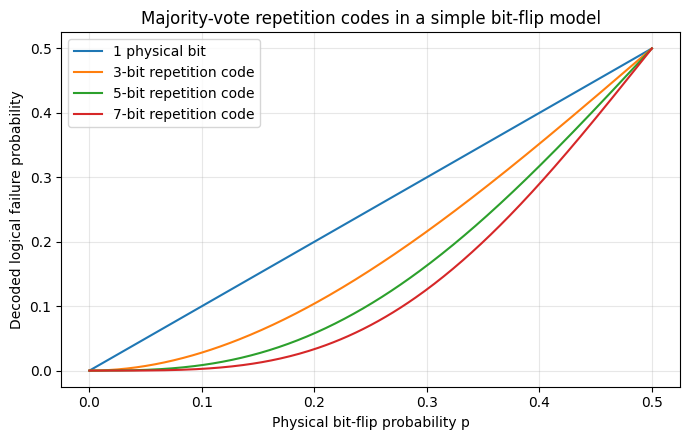

In [13]:
p_grid = np.linspace(0.0, 0.5, 301)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(p_grid, p_grid, label="1 physical bit")
for n in [3, 5, 7]:
    ax.plot(
        p_grid,
        [repetition_logical_failure_probability(n, float(p)) for p in p_grid],
        label=f"{n}-bit repetition code",
    )
ax.set_xlabel("Physical bit-flip probability p")
ax.set_ylabel("Decoded logical failure probability")
ax.set_title("Majority-vote repetition codes in a simple bit-flip model")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(ASSET_DIR / "qec_repetition_threshold_style.png", dpi=180, bbox_inches="tight")
plt.show()


The longer repetition codes do better at small $p$, but all curves meet at $p = 0.5$. Above $p = 0.5$, majority vote would usually pick the wrong value. Real quantum codes protect against richer noise and need a decoder that uses syndrome measurements, not just a final majority vote.


## 10. Beyond the toy model

The three-qubit repetition code protects against one bit flip. It does **not** protect a general quantum state from all possible errors.

A useful way to see the limitation is to remember that a general qubit can be written as

$$
|\psi\rangle = \alpha |0\rangle + \beta |1\rangle.
$$

A bit flip changes $|0\rangle$ to $|1\rangle$ and $|1\rangle$ to $|0\rangle$. A phase flip leaves the measurement values alone but changes the relative sign of the superposition. The three-qubit bit-flip code does not detect that phase error in the same basis.

More complete QEC codes use **stabilizer checks**. A stabilizer check is a measurement that reveals error information without revealing the encoded state itself. The surface code is a leading family of stabilizer codes because its checks are local on a two-dimensional grid and it has a threshold: below a sufficiently low physical error rate, increasing the code distance can reduce the logical error rate.

Present-day devices still have noisy gates, measurement errors, leakage, crosstalk, and calibration drift. QEC research is about making the logical error rate improve despite those costs.


## 11. Optional: run a tiny version on real IBM quantum hardware

This section is disabled by default.

```python
RUN_ON_IBM = False
```

The optional run uses Qiskit Runtime `SamplerV2` in job mode with `mode=backend`. It does not use a session. The batch is intentionally small: three circuits with 256 shots each by default.

To run it, set an environment variable outside the notebook:

```bash
export QISKIT_IBM_TOKEN="your-api-key"
# Optional if you want to select a specific instance:
export QISKIT_IBM_INSTANCE="your-instance-crn-or-name"
```

Do not paste tokens into the notebook, do not print tokens, and do not save credentials into the repository. IBM Open Plan usage is limited, so check your account usage before enabling this cell.


In [ ]:
RUN_ON_IBM = False
IBM_SHOTS = 256

hardware_circuits = [
    make_unencoded_memory_circuit(initial_state=1),
    make_repetition_memory_circuit(initial_state=1),
    make_repetition_known_flip_circuit(initial_state=1, flipped_qubit=0),
]

print(f"Prepared {len(hardware_circuits)} circuits x {IBM_SHOTS} shots = {len(hardware_circuits) * IBM_SHOTS} shots.")
print("Hardware run enabled?", RUN_ON_IBM)


Prepared 3 circuits x 256 shots = 768 shots.
Hardware run enabled? False


In [ ]:
def run_ibm_sampler_optional(
    circuits: Sequence[QuantumCircuit],
    shots: int = IBM_SHOTS,
) -> list[dict[str, int]] | None:
    """Run a tiny SamplerV2 job on IBM hardware when RUN_ON_IBM is True."""
    if not RUN_ON_IBM:
        print("IBM hardware run skipped. Set RUN_ON_IBM = True only after checking your IBM plan usage.")
        return None

    token = os.getenv("QISKIT_IBM_TOKEN")
    if not token:
        print("QISKIT_IBM_TOKEN is not set. Use the Aer simulator results above instead.")
        return None

    try:
        from qiskit.transpiler import generate_preset_pass_manager
        from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RuntimeSampler
    except ImportError as exc:
        print(f"qiskit-ibm-runtime is not available: {exc}")
        return None

    channel = os.getenv("QISKIT_IBM_CHANNEL", "ibm_quantum_platform")
    instance = os.getenv("QISKIT_IBM_INSTANCE") or None
    service = QiskitRuntimeService(channel=channel, token=token, instance=instance)

    def usable_backend(backend) -> bool:
        try:
            status = backend.status()
            configuration = backend.configuration()
            return bool(status.operational) and not bool(configuration.simulator)
        except Exception:
            return False

    try:
        backend = service.least_busy(min_num_qubits=3, filters=usable_backend)
    except Exception as exc:
        print(f"Could not select an IBM backend: {exc}")
        return None

    backend_name = getattr(backend, "name", "selected_backend")
    print(f"Selected backend: {backend_name}")
    print(f"Submitting {len(circuits)} circuits x {shots} shots = {len(circuits) * shots} shots.")

    try:
        pass_manager = generate_preset_pass_manager(backend=backend, optimization_level=1)
        isa_circuits = pass_manager.run(list(circuits))
        sampler = RuntimeSampler(mode=backend)
        job = sampler.run(isa_circuits, shots=shots)
        result = job.result()
    except Exception as exc:
        print(f"IBM hardware job did not complete: {exc}")
        return None

    return [counts_from_sampler_result_item(item) for item in result]

ibm_counts = run_ibm_sampler_optional(hardware_circuits, shots=IBM_SHOTS)
ibm_counts


IBM hardware run skipped. Set RUN_ON_IBM = True only after checking your IBM plan usage.


If you enable the hardware run, decode the returned bitstrings with the same `logical_error_rate` function. Treat the result as a small hardware-friendly demonstration. It is not an active QEC experiment with repeated syndrome measurements and feedback.


## Common mistakes

> **Confusing detection with correction.** Detecting that an error may have happened is not the same as correcting it. In this tutorial, final measurement and majority vote correct one bit flip only after the circuit has ended.
>
> **Assuming QEC violates no-cloning.** QEC encodes information into correlations among qubits. It does not make independent copies of an unknown quantum state.
>
> **Thinking the three-qubit repetition code corrects all quantum errors.** It corrects one bit flip in this simple setting. It does not protect against general phase errors.
>
> **Forgetting that extra gates can add noise.** In the clean simulation, encoding gates are perfect. On hardware, those gates can introduce errors.
>
> **Treating simulator results as hardware results.** The plots above are simulator results with an injected bit-flip model. Hardware results should be reported only if the hardware cell was actually run.


## What to try next

A natural extension is the phase-flip repetition code. The idea is to place Hadamard gates before and after the memory step so that phase flips become bit flips in the rotated basis. After that, study stabilizer measurements and the surface code.

For a first project, keep the circuits small. Change one thing at a time: the physical error rate, the number of shots, the repetition length, or whether measurement error is included.


## Contributor note

Contributor note: I first found QEC approachable by starting with the three-qubit repetition code, because it turns the abstract idea of a logical qubit into a simple majority-vote experiment. If you are new to the field, begin with small circuits like the ones above, then move to stabilizers and surface-code tutorials.


## References

1. Michael A. Nielsen and Isaac L. Chuang, *Quantum Computation and Quantum Information: 10th Anniversary Edition*, Cambridge University Press, 2010.
2. Peter W. Shor, "Scheme for reducing decoherence in quantum computer memory," *Physical Review A* 52, R2493, 1995.
3. Andrew M. Steane, "Error Correcting Codes in Quantum Theory," *Physical Review Letters* 77, 793, 1996.
4. Daniel Gottesman, *Stabilizer Codes and Quantum Error Correction*, Ph.D. thesis, Caltech, arXiv:quant-ph/9705052, 1997.
5. Eric Dennis, Alexei Kitaev, Andrew Landahl, and John Preskill, "Topological quantum memory," *Journal of Mathematical Physics* 43, 4452, 2002.
6. Austin G. Fowler, Matteo Mariantoni, John M. Martinis, and Andrew N. Cleland, "Surface codes: Towards practical large-scale quantum computation," *Physical Review A* 86, 032324, 2012.
7. Google Quantum AI, "Suppressing quantum errors by scaling a surface code logical qubit," *Nature* 614, 676-681, 2023.
8. Google Quantum AI and Collaborators, "Quantum error correction below the surface code threshold," *Nature* 638, 920-926, 2025.
9. Qiskit documentation: https://quantum.cloud.ibm.com/docs/en/api/qiskit
10. Qiskit Aer noise model guide: https://quantum.cloud.ibm.com/docs/en/guides/build-noise-models
11. Qiskit Runtime SamplerV2 API: https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/sampler-v2
12. IBM Quantum plans overview: https://quantum.cloud.ibm.com/docs/en/guides/plans-overview
